In [1]:
import pandas as pd
import os
import glob
from tqdm import tqdm
import cudf as cd
from numba import cuda
import time
import matplotlib.pyplot as plt


In [2]:
def transfer_times(data):
    times = []
    iterations = 10
    # print_gpu_memory_usage_pynvml(device_id=0)
    for i in range(iterations):
        cuda.synchronize()
        start_time = time.perf_counter()

        cudf_df = cd.DataFrame.from_pandas(data)

        cuda.synchronize()
        end_time = time.perf_counter()
        times.append(end_time - start_time)

        # print(type(cudf_df))
        # del cudf_df
    # print_gpu_memory_usage_pynvml(device_id=0)
    elapsed_time = sum(times) / iterations
    return elapsed_time * 1000

In [3]:
def ideal_transfer_time(data):
    memory_usage = data.memory_usage(deep=True).sum()
    memory_usage = memory_usage / 10**9
    ideal_time = memory_usage / 16  # bandwidith is 16GB/s
    # print(memory_usage)
    return ideal_time * 1000, memory_usage

In [4]:
import pynvml


def format_bytes(size):
    """Converts bytes to a human-readable format (GB, MB, KB)."""
    power = 2**10  # 1024
    n = 0
    power_labels = {0: "B", 1: "KB", 2: "MB", 3: "GB", 4: "TB"}
    while size > power and n < max(power_labels.keys()):
        size /= power
        n += 1
    return f"{size:.2f} {power_labels[n]}"


def print_gpu_memory_usage_pynvml(device_id=0):
    """Prints GPU memory usage using pynvml for a specific device."""
    try:
        pynvml.nvmlInit()
        handle = pynvml.nvmlDeviceGetHandleByIndex(device_id)
        mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)

        print(f"--- GPU Memory (Device {device_id}) via pynvml ---")
        print(f"Total : {format_bytes(mem_info.total)}")
        print(f"Used  : {format_bytes(mem_info.used)}")
        print(f"Free  : {format_bytes(mem_info.free)}")
        print(
            "-" * (len(f"Total : {format_bytes(mem_info.total)}") + 4)
        )  # Dynamic width

    except pynvml.NVMLError as error:
        print(f"Failed to get GPU memory info using pynvml: {error}")
        print("Ensure NVIDIA drivers are installed and pynvml is compatible.")
    finally:
        try:
            pynvml.nvmlShutdown()
        except pynvml.NVMLError:
            pass

In [5]:
input_dir = "/home/jupyter/generated_dataframes_mixed"
file_pattern = os.path.join(input_dir, "*.parquet")
files = glob.glob(file_pattern)

results_list = []

for file in tqdm(files):
    if ".parquet" in file:
        data = pd.read_parquet(file)
        elapsed_time = transfer_times(data)
        ideal_time, memory_usage = ideal_transfer_time(data)
        # print(f"elapsed_time {elapsed_time} ms")
        # print(f"ideal_time {ideal_time} ms")
        # print(f"memory usage {memory_usage} GB")
        results_list.append(
            {
                "memory_usage": memory_usage,
                "elapsed_time": elapsed_time,
                "ideal_time": ideal_time,
                "n_cols": len(data.columns),
                "n_rows": len(data),
            }
        )
        del data

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [15:16<00:00,  5.46it/s]


In [6]:
input_dir = "/home/jupyter/generated_dataframes_mixed_100k"
file_pattern = os.path.join(input_dir, "*.parquet")
files = glob.glob(file_pattern)


for file in tqdm(files):
    if ".parquet" in file:
        data = pd.read_parquet(file)
        elapsed_time = transfer_times(data)
        ideal_time, memory_usage = ideal_transfer_time(data)
        # print(f"elapsed_time {elapsed_time} ms")
        # print(f"ideal_time {ideal_time} ms")
        # print(f"memory usage {memory_usage} GB")
        results_list.append(
            {
                "memory_usage": memory_usage,
                "elapsed_time": elapsed_time,
                "ideal_time": ideal_time,
                "n_cols": len(data.columns),
                "n_rows": len(data),
            }
        )
        del data

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [48:09<00:00,  1.04it/s]


In [8]:
results_df = pd.DataFrame(results_list)

In [9]:
(
    results_df["n_rows"].max(),
    results_df["n_rows"].min(),
    results_df["n_cols"].min(),
    results_df["n_cols"].max(),
)

(499621, 1027, 1, 10)

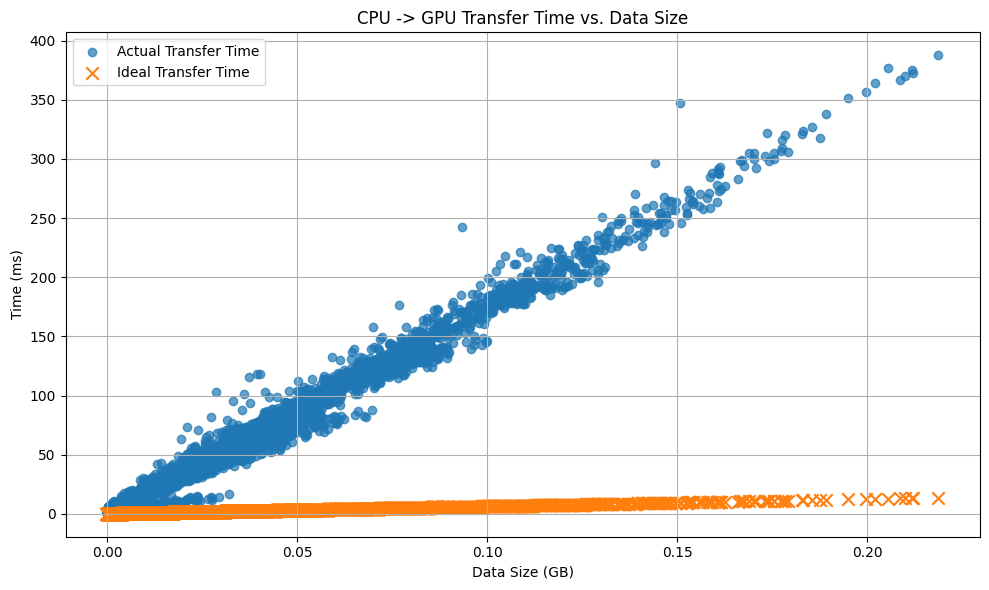

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(
    results_df["memory_usage"],
    results_df["elapsed_time"],
    label="Actual Transfer Time",
    alpha=0.7,
)
plt.scatter(
    results_df["memory_usage"],
    results_df["ideal_time"],
    label="Ideal Transfer Time",
    marker="x",
    s=80,
)
# Optional: Plot lines if data sizes are somewhat ordered
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['elapsed_time'], marker='o', linestyle='-', label='Actual Transfer Time')
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['ideal_time'], marker='x', linestyle='--', label='Ideal Transfer Time')
plt.xlabel("Data Size (GB)")
plt.ylabel("Time (ms)")
plt.title("CPU -> GPU Transfer Time vs. Data Size")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Training set features shape: (6400, 3)
Testing set features shape: (1600, 3)

Training Linear Regression model (features: ideal_time, memory_gb)...
Training complete.

--- Linear Regression Model Parameters ---
Equation: Actual_Time ≈ ( (1862.6089 * Memory_GB) + 5.3922
Coefficient for memory_gb: 1862.6089, -0.0000, -0.5636
Intercept:                 5.3922 ms

--- Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE):      34.0945 (ms^2)
  Root Mean Squared Error (RMSE):5.8391 (ms)
  Mean Absolute Error (MAE):     3.4058 (ms)
  R-squared (R²):                0.9877


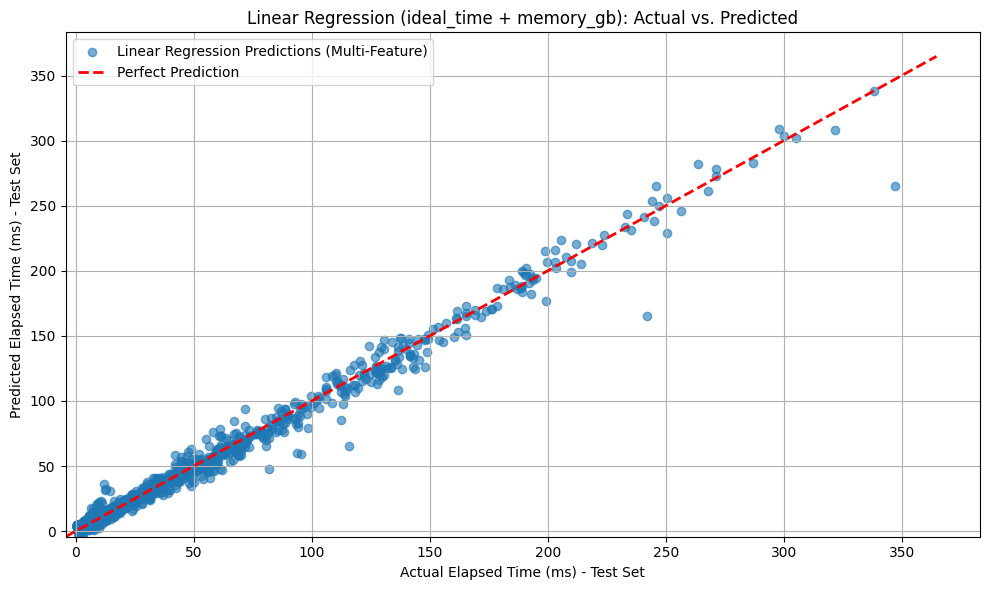

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- Assume results_df is already populated ---
# It MUST contain 'elapsed_time', 'ideal_time', and 'memory_gb'
# Example creation if needed:
# results_list = [{'elapsed_time': 5.2, 'ideal_time': 1.1, 'memory_gb': 0.001, ...}, {...}]
# results_df = pd.DataFrame(results_list)
# -----------------------------------------------------------------------

# Check if DataFrame and necessary columns exist
if "results_df" not in locals() or results_df.empty:
    print("Error: 'results_df' not found or is empty. Please load your results.")
elif not all(
    col in results_df.columns for col in ["elapsed_time", "ideal_time", "memory_usage"]
):
    print(
        "Error: 'results_df' must contain 'elapsed_time', 'ideal_time', and 'memory_gb' columns."
    )
else:
    # 1. Prepare Data
    # Define features (X) and target (y)
    feature_columns = ["memory_usage", "n_rows", "n_cols"]  # <<< Added memory_gb
    target_column = "elapsed_time"
    all_columns = feature_columns + [target_column]

    # Drop rows where any required column has NaN
    # results_df_clean = results_df.dropna(subset=all_columns)

    # if results_df_clean.empty:
    #     print("No valid data points remain after removing NaNs.")
    # else:
    # print(f"Using {len(results_df_clean)} data points for modeling.")

    # Extract features (X) - Should be 2D: (n_samples, n_features)
    X = results_df[feature_columns].values
    # Extract target (y) - Should be 1D: (n_samples,)
    y = results_df[target_column].values

    # 2. Split Data into Training and Testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print(f"\nTraining set features shape: {X_train.shape}")
    print(f"Testing set features shape: {X_test.shape}")

    # 3. Create and Train the Linear Regression Model
    print("\nTraining Linear Regression model (features: ideal_time, memory_gb)...")
    lin_reg_model_multi = LinearRegression()
    lin_reg_model_multi.fit(X_train, y_train)
    print("Training complete.")

    # 4. Get Model Parameters (Coefficients)
    # The order matches the feature_columns list
    # coef_ideal_time = lin_reg_model_multi.coef_[0]
    coef_memory_gb = lin_reg_model_multi.coef_[0]
    coef_n_rows = lin_reg_model_multi.coef_[1]
    coef_n_cols = lin_reg_model_multi.coef_[2]
    intercept = lin_reg_model_multi.intercept_

    print("\n--- Linear Regression Model Parameters ---")
    print(
        f"Equation: Actual_Time ≈ ( ({coef_memory_gb:.4f} * Memory_GB) + {intercept:.4f}"
    )
    # print(f"Coefficient for ideal_time:  {coef_ideal_time:.4f}")
    print(
        f"Coefficient for memory_gb: {coef_memory_gb:.4f}, {coef_n_rows:.4f}, {coef_n_cols:.4f}"
    )
    print(f"Intercept:                 {intercept:.4f} ms")

    # 5. Make Predictions on the Test Set
    y_pred = lin_reg_model_multi.predict(X_test)

    # 6. Evaluate the Model on the Test Set
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n--- Model Evaluation (on Test Set) ---")
    print(f"  Mean Squared Error (MSE):      {mse:.4f} (ms^2)")
    print(f"  Root Mean Squared Error (RMSE):{rmse:.4f} (ms)")
    print(f"  Mean Absolute Error (MAE):     {mae:.4f} (ms)")
    print(f"  R-squared (R²):                {r2:.4f}")
    # Compare this R² to the model using only ideal_time. Did it improve much?

    # 7. Visualize Predictions vs. Actuals (on Test Set) - Still useful
    plt.figure(figsize=(10, 6))
    plt.scatter(
        y_test, y_pred, alpha=0.6, label="Linear Regression Predictions (Multi-Feature)"
    )
    min_val = min(min(y_test), min(y_pred)) * 0.95
    max_val = max(max(y_test), max(y_pred)) * 1.05
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Perfect Prediction",
    )
    plt.xlabel("Actual Elapsed Time (ms) - Test Set")
    plt.ylabel("Predicted Elapsed Time (ms) - Test Set")
    plt.title("Linear Regression (ideal_time + memory_gb): Actual vs. Predicted")
    plt.legend()
    plt.grid(True)
    plt.xlim(left=min_val)
    plt.ylim(bottom=min_val)
    plt.tight_layout()
    plt.show()

    # Optional: Residual Plot
    # ... (code for residual plot as before) ...

In [10]:
features = {
    "memory_usage": 0.003,
}
x_test = pd.DataFrame([features])
xgb_model.predict(x_test)

array([10.28443], dtype=float32)

In [19]:
10.72 + (0.02 / 16) * 1000

11.97

In [21]:
3.1 / 1000

0.0031

In [16]:
results_df["n_cols"].max()

10